### Import libraries

In [7]:
from pathlib import Path
import SimpleITK as sitk
from platipy.dicom.io.nifti_to_rtstruct import convert_nifti
import matplotlib.pyplot as plt

from srmip import read_image, Image
from srmip.dicom_to_nifti.dicom_to_nifti import read_dicom_rtstruct

## READ DICOM AND SAVE NII 

### Define path

In [2]:
# dicom_path = Path(__file__).parents[1] / "tests" / "Dicom" / "IBSI1_CT_phantom" / "image"
dicom_path = Path.cwd().parent / "tests" / "Dicom" / "IBSI1_CT_phantom"
outputs = Path.cwd().parent / "src" /"wrk"
dicom_path, outputs

(WindowsPath('C:/Users/ubeira.mariagiulia/OneDrive - Ospedale San Raffaele/progetti_SR/PycharmProjects/srmip/tests/Dicom/IBSI1_CT_phantom'),
 WindowsPath('C:/Users/ubeira.mariagiulia/OneDrive - Ospedale San Raffaele/progetti_SR/PycharmProjects/srmip/src/wrk'))

### Read original dicom image and dicom rtstruct

In [5]:
# Read original dicom image
image_ct = read_image(dicom_path / "CT_00000")
# Read original dicom rtstruct
path_rt = list((dicom_path).glob("RTst_*/*.dcm"))[0]
structures = read_dicom_rtstruct(path_rt, image_ct)
print(structures)

[RTStructure(name='GTV-1', mask=<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'itk::simple::Image *' at 0x00000193ABC25CB0> >)]


In [11]:
image_ct.GetSize()

(204, 201, 60)

### Plot image and first structure

In [12]:
image_array = sitk.GetArrayFromImage(image_ct)
mask_array = sitk.GetArrayFromImage(structures[0].mask)
image_array.shape, mask_array.shape

((60, 201, 204), (60, 201, 204))

In [14]:
index = 30

Text(0.5, 1.0, 'original * first mask')

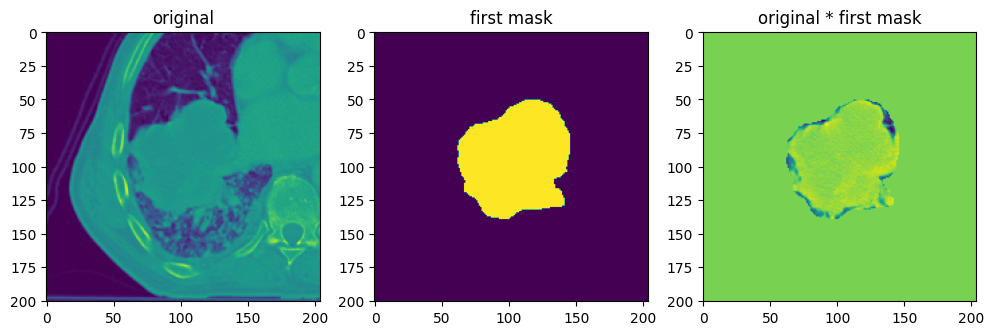

In [29]:
fig, ax = plt.subplots(1,3, figsize=(12,35))
ax[0].imshow(image_array[index])
ax[0].set_title('original')
ax[1].imshow(mask_array[index])
ax[1].set_title('first mask')
ax[2].imshow(image_array[index]*mask_array[index])
ax[2].set_title('original * first mask')

### Define path where to save nii files

In [9]:
save_path = outputs / "prove"
save_path.mkdir(exist_ok=True, parents=True)

### Save nifti (image and rt structure)

In [10]:
image_ct.write_image(save_path / "img.nii.gz")
sitk.WriteImage(structures[0].mask, str(save_path / f"{structures[0].name}.nii.gz"))